In [3]:
import pandas as pd 

In [4]:
df = pd.read_csv('churn-bigml-80.csv')

In [5]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [7]:
df = df.drop(['State'],axis=1)
df['International plan'] = df['International plan'].map({'Yes':1,'No':0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes':1,'No':0})
df['Churn'] = df['Churn'].map({True:1,False:0})

X = df.drop('Churn',axis=1)
y = df['Churn']

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [11]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall:',recall_score(y_test,y_pred))

Accuracy: 0.8614232209737828
Precision: 0.5806451612903226
Recall: 0.22784810126582278


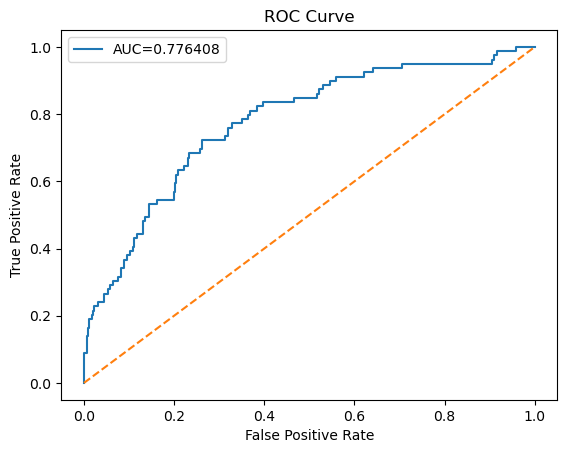

In [12]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt

fpr,tpr,_ = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f'AUC={auc:2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [13]:
print('ROC-AUC:',auc)

ROC-AUC: 0.7764084017248574


In [14]:
import numpy as np

coef_df = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_[0],
    'Odds Ratio':np.exp(model.coef_[0])
})

print(coef_df.sort_values(by='Odds Ratio',ascending=False))

                   Feature  Coefficient  Odds Ratio
2       International plan     2.144451    8.537351
17  Customer service calls     0.477543    1.612108
14      Total intl minutes     0.089025    1.093108
16       Total intl charge     0.065306    1.067486
5        Total day minutes     0.020347    1.020555
4    Number vmail messages     0.011551    1.011618
8        Total eve minutes     0.008174    1.008208
11     Total night minutes     0.003890    1.003897
6          Total day calls     0.003689    1.003695
0           Account length     0.001106    1.001106
9          Total eve calls     0.000739    1.000740
1                Area code    -0.001227    0.998774
12       Total night calls    -0.001820    0.998182
13      Total night charge    -0.021493    0.978736
10        Total eve charge    -0.030972    0.969502
7         Total day charge    -0.038924    0.961824
15        Total intl calls    -0.113752    0.892479
3          Voice mail plan    -1.292798    0.274502


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]